In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import k3d
import lc_reconstruction_analysis.utils as utils
import lc_reconstruction_analysis.dendritic as dendritic
import lc_reconstruction_analysis.clustering as clustering
import lc_reconstruction_analysis.axon as axon
import lc_reconstruction_analysis.correlation as correlation
%matplotlib inline

In [2]:
# Define path to data
DATA_DIR = Path("/data/")
# Load data frame of cells, and networkx graphs
dataDF, graphs = utils.load_cells(DATA_DIR)

Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N064-68221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N051-685221 -YP.json
Missing structure axon for /data/685221_12_5_24/Complete_annotated/N064-685221-JN.json
Missing structure dendrite for /data/685221_12_5_24/Complete_annotated/N025-685221-PG.json
Missing structure dendrite for /data/648434_12_5_24/Complete_annotated/N024-648434-SS.json
Error finding structures for: N025-685221-PG, dropping from dataframe
Error finding structures for: N064-68221-JN, dropping from dataframe
Error finding structures for: N051-685221 -YP, dropping from dataframe
Error finding structures for: N064-685221-JN, dropping from dataframe
Error finding structures for: N024-648434-SS, dropping from dataframe


In [3]:
# Exclude any neurons that need to be excluded
excludeList = [ # Look like MY cells mistakenly included in LC batch
    "N039-685222-AK", # ibAndSC
    "N040-685222-VM",
    "N066-685221-JN", # ibAndSC
    "N068-685221-HD",
    "N067-685221-HS"
]

dataDF = dataDF.drop(dataDF[dataDF["Graph"].isin(excludeList)].index)

In [4]:
# Add annotation for brains with coiled spinal cords
dataDF["completeSC"] = False
dataDF.loc[dataDF["Sample"].isin(['721332']),"completeSC"] = True
sc_dataDF = dataDF[dataDF["completeSC"]]

# Manually annotate spinal cord projections
projectsSC = ['N030-685222-NM', 'N048-685221-VM', 'N044-685221-DS', 'N014-685221-YV', 'N022-685221-YP', 'N054-685221-HS', 'N052-685221-BP', 'N041-685221-JN', 'N038-685221-HS', 'N005-685222-YP',
 'N021-685222-NM', 'N016-685221-PG', 'N035-685221-DS', 'N016-685222-YP', 'N004-685222-BP', 'N010-685222-VM', 'N001-685221-PG', 'N043-685221-HD', 'N006-685222-DS', 'N007-685222-BP', 'N026-685222-SA', 
 'N051-685221-YP', 'N056-685221-AK', 'N042-685221-HD', "N015-721332-JG", "N017-721332-PP", "N009-648434-KV", "N045-685221-VM","N034-685222-HD","N034-685221-VM","N057-685221-AP","N036-685221-YP", 
 "N020-685221-BP", "N015-685222-VM", "N055-685221-JN", "N058-685221-JN", "N046-685221-SA", "N060-685221-YV", "N025-648434-PG", "N013-685221-DS", "N012-685222-BP", "N013-685222-DS", "N050-685221-HD", 
 "N024-685221-VM", "N008-685222-HD", "N009-685222-SP", "N024-685222-AP", "N059-685221-SA", "N012-648434-JN", "N006-648434-JN", "N025-685222-SA", "N061-685221-YP", "N030-685221-VM", "N026-648434-PG",
 "N001-721332-HP","N002-721332-SA","N004-721332-VM", "N007-721332-FB", "N014-721332-MB", "N021-721332-MB"]

# Add labels to dataframe
dataDF["isSpinalProjecting"] = False
dataDF.loc[dataDF["Graph"].isin(projectsSC),"isSpinalProjecting"] = True

In [5]:
dataDF

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,completeSC,isSpinalProjecting
0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.676000,4571.162500,4612.849100,False,False,True
62,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.217200,4145.213600,4709.684200,True,False,False
131,N001-721332-HP,N001,721332,HP,Dbh-Cre-KI/wt,10254.754578,4470.771631,4613.168027,False,True,True
63,N002-685222-HD,N002,685222,HD,Dbh-Cre-KI/wt,10559.816400,4318.414600,4715.990100,True,False,False
113,N002-721332-SA,N002,721332,SA,Dbh-Cre-KI/wt,10642.887060,4620.827505,4609.366932,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
56,N059-685221-SA,N059,685221,SA,Dbh-Cre-KI/wt,10256.332400,4983.984500,4522.742700,True,False,True
37,N060-685221-YV,N060,685221,YV,Dbh-Cre-KI/wt,10170.916700,4731.238300,4769.321200,False,False,True
57,N061-685221-YP,N061,685221,YP,Dbh-Cre-KI/wt,10094.263100,5153.054000,4674.397200,False,False,True
24,N063-685221-HS,N063,685221,HS,Dbh-Cre-KI/wt,10500.650800,4364.168700,5071.783300,False,False,False


In [8]:
# Get axon branching
axon_branch_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2] # get axonal branches
    axon_branch_dict[name] = len(axon_branch_nodes)

dend_branch_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)

# # Combine length and branching into one dataframe
# metricsDF = pd.concat([df.sum(axis=1) / 10000, pd.Series(axon_branch_dict)], axis = 1)
# metricsDF = metricsDF.rename(columns = {0 : "Total Length (cm)", 1 : "Axon Branches"})
# metricsDF

In [10]:
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get dendrite subgraph
    x = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(x[u][v]["weight"] for u, v in x.edges) # total length

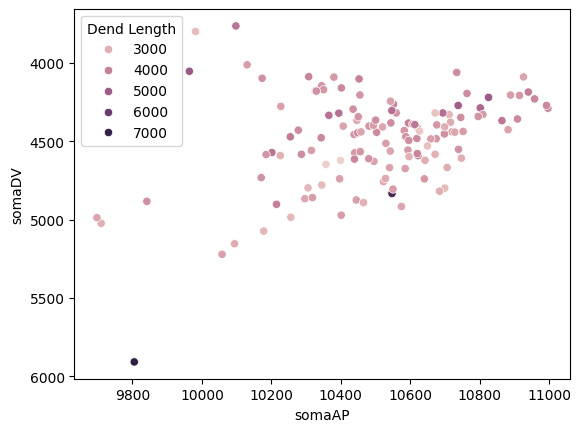

In [11]:
sns.scatterplot(pd.merge(dataDF, pd.Series(dend_length_dict, name = "Dend Length"), left_on = "Graph", right_index =True, how = "left"), x = "somaAP", y = "somaDV", hue = "Dend Length")
plt.gca().invert_yaxis() # Invert the y-axis

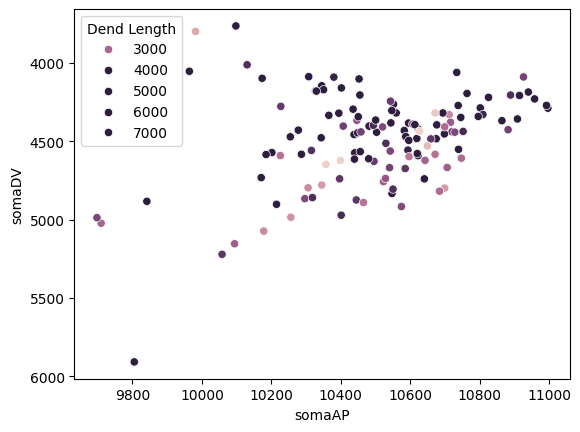

In [12]:
sns.scatterplot(pd.merge(dataDF, pd.Series(dend_length_dict, name = "Dend Length"), left_on = "Graph", right_index =True, how = "left"), x = "somaAP", y = "somaDV", hue = "Dend Length", hue_norm=(2500,3500))
plt.gca().invert_yaxis() # Invert the y-axis

In [14]:
pd.merge(dataDF, df.divide(df.sum(axis = 1), axis = 0), left_on = "Graph", right_index =True, how = "left").head(3)

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,completeSC,...,Isocortex,HY,fiber tracts,Other,VS,CNU,HPF,CTXsp,OLF,CB
0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.676000,4571.162500,4612.849100,False,False,...,0.002570,0.020860,0.016341,0.173288,0.000525,0.015713,0.000000,0.000000,0.000000,0.000000
62,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.217200,4145.213600,4709.684200,True,False,...,0.657372,0.028757,0.046826,0.009400,0.000000,0.036611,0.093728,0.019107,0.047268,0.006982
131,N001-721332-HP,N001,721332,HP,Dbh-Cre-KI/wt,10254.754578,4470.771631,4613.168027,False,True,...,0.000000,0.000000,0.011759,0.779280,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
dataDF["somaAP"].max()

10996.724

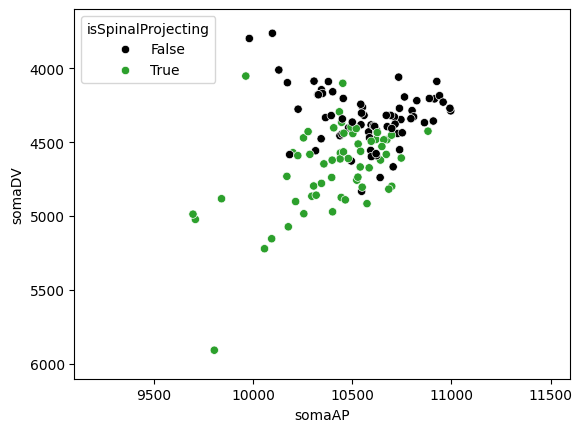

In [16]:
sns.scatterplot(pd.merge(dataDF, df.divide(df.sum(axis = 1), axis = 0), left_on = "Graph", right_index =True, how = "left"),
                x = "somaAP", y = "somaDV", hue = "isSpinalProjecting", palette = {False:"k", True:"tab:green"})
plt.xlim([9100, 11600])
plt.ylim([3600, 6100])
plt.gca().invert_yaxis() # Invert the y-axis
plt.savefig("../results/spinal projecting soma location.png",dpi=300, bbox_inches='tight')

## Projection figures

In [18]:
# Projection regions to look at
sorted_rois = ["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB","CB","P","MY","Other"]

In [19]:
# Build length dataframe
df = clustering.build_length_df(dataDF,graphs,DATA_DIR,normalize_df=False)

In [20]:
# Get basic features, e.g. branching and length
axon_branch_dict = {}
dend_branch_dict = {}
dend_length_dict = {}
for name in dataDF["Graph"]:
    graph = graphs[name]
    # Get axonal branches
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)
    # Get dendritic branches
    dend_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 3] # get dendritic branches
    dend_branch_dict[name] = len(dend_branch_nodes)
    # Get dendritic lengths
    dend_graph = graph.subgraph([node for node in graph.nodes() if (graph.nodes[node]["structure_id"] == 3) or (graph.nodes[node]["structure_id"] == 1)])
    dend_length_dict[name] = sum(dend_graph[u][v]["weight"] for u, v in dend_graph.edges) # total length

# Combine length and branching into one dataframe
metricsDF = pd.concat([pd.Series(df.sum(axis=1) / 10000, name = "Axon Length (cm)"),
            pd.Series(axon_branch_dict, name = "Axon Branches"), 
            pd.Series(dend_length_dict, name = "Dendrite Length (cm)") / 10000,
            pd.Series(dend_branch_dict, name = "Dendrite Branches")], axis = 1)
metricsDF.head(3)

,Axon Length (cm),Axon Branches,Dendrite Length (cm),Dendrite Branches
N001-685221-PG,14.318932,103.0,0.432141,7.0
N003-685221-HS,39.771467,418.0,0.357634,9.0
N005-685221-JN,42.695832,646.0,0.442914,22.0


In [21]:
# Get normalized features
normDF = pd.concat([df.divide(df.sum(axis = 1), axis = 0)[sorted_rois],
                    pd.Series(metricsDF["Axon Length (cm)"] / metricsDF["Axon Length (cm)"].max(), name = "Norm Axon Length"),
                    pd.Series(metricsDF["Axon Branches"] / metricsDF["Axon Branches"].max(), name = "Norm Axon Branches"),
                    pd.Series(metricsDF["Dendrite Length (cm)"] / metricsDF["Dendrite Length (cm)"].max(), name = "Norm Dend Length"),
                    pd.Series(metricsDF["Dendrite Branches"] / metricsDF["Dendrite Branches"].max(), name = "Norm Dend Branches")], axis = 1)
normDF.head(3)

,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Norm Axon Length,Norm Axon Branches,Norm Dend Length,Norm Dend Branches
N001-685221-PG,0.000000,0.002570,0.000000,0.000000,0.015713,0.105158,0.020860,0.255037,0.000000,0.071944,0.338564,0.173288,0.197319,0.066796,0.605091,0.145833
N003-685221-HS,0.004117,0.715633,0.020381,0.000475,0.026497,0.008416,0.021058,0.009686,0.000310,0.025406,0.107696,0.016228,0.548062,0.271077,0.500766,0.187500
N005-685221-JN,0.059003,0.717188,0.002060,0.002088,0.017548,0.015278,0.023731,0.077711,0.002312,0.018196,0.000000,0.016875,0.588361,0.418936,0.620176,0.458333


In [22]:
# Merge dataframes
fullDF = pd.merge(pd.merge(dataDF,normDF,left_on="Graph", right_index=True, how = "left"), 
         metricsDF, left_on = "Graph", right_index = True, how = "left")
fullDF["Most Length"] = [sorted_rois[i] for i in np.argmax(fullDF[sorted_rois],axis=1)] # Add top projection target

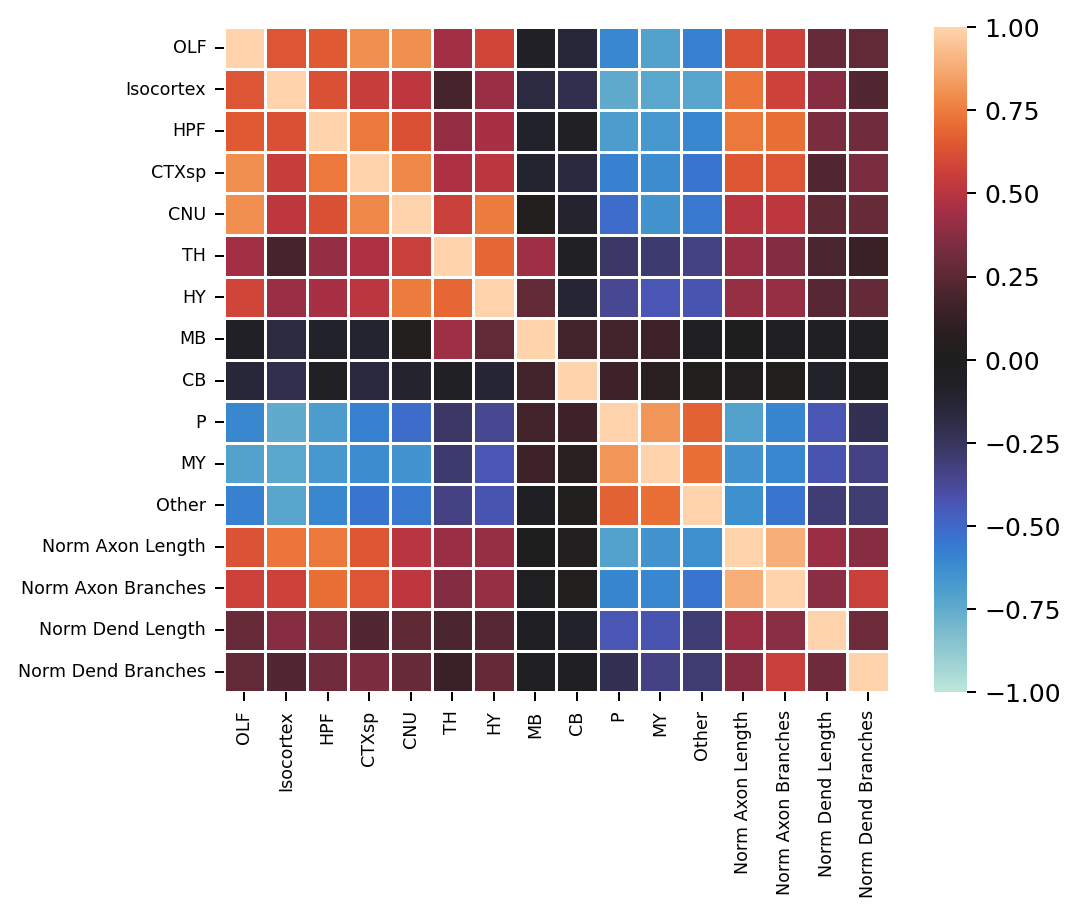

In [25]:
# Get correlation between features
corr_features = normDF.columns
corrMatrix = fullDF[corr_features].corr(method = "spearman")

# Do plotting
plt.figure(dpi=180)
sns.heatmap(corrMatrix, square = True, linewidths=.5, vmin = -1, vmax = 1, center = 0, cmap = "icefire")
plt.xticks(fontsize=7);
plt.yticks(fontsize=7);
plt.savefig("../results/Correlation matrix (spearman, proj + neuron features, diverging cmap).svg",
            dpi=300, bbox_inches='tight', transparent = True)

## Sort by top projection targets

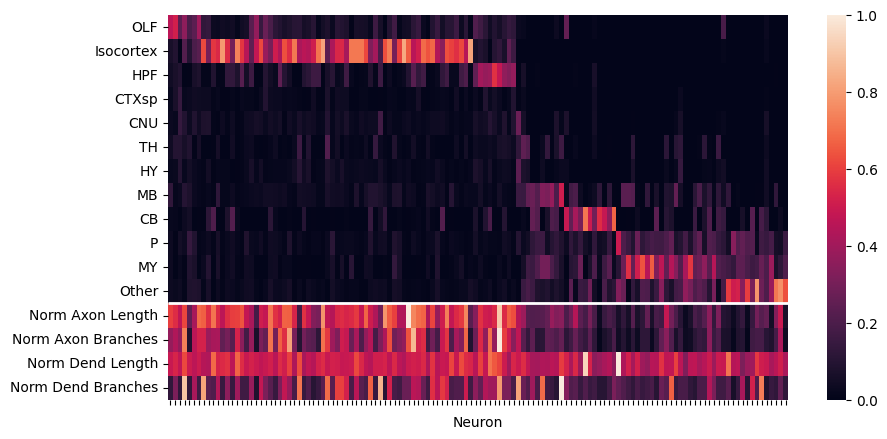

In [24]:
# Plot heatmap of projections
plotDF = fullDF.copy()
# Establish projection based sorting
sortProjDict = {}
for i, col in enumerate(sorted_rois):
    sortProjDict[col] = i
plotDF["Most Length"] = plotDF["Most Length"].map(sortProjDict)
plotDF = plotDF.sort_values("Most Length")[normDF.columns]

# Do plotting
plt.figure(figsize=(10,5))
sns.heatmap(plotDF.T, xticklabels = True, yticklabels = True)
# Clean up axes
plt.gca().set_xticklabels([])
plt.xlabel("Neuron")
plt.hlines([12], *plt.xlim(), colors = "white", linewidth = 2)
plt.savefig("../results/bilateral proj + neuron features heatmap sorted by top projection target.svg",
            dpi=300,bbox_inches='tight', transparent = True)

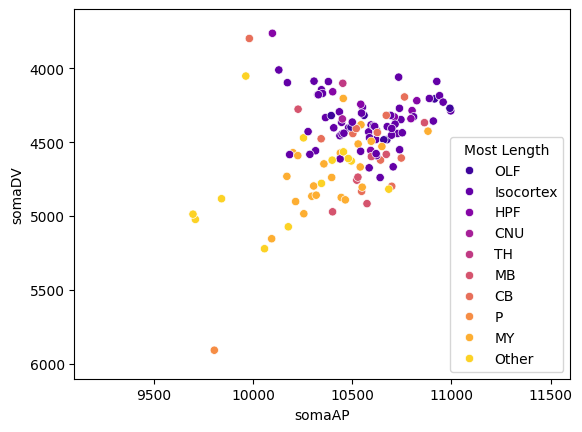

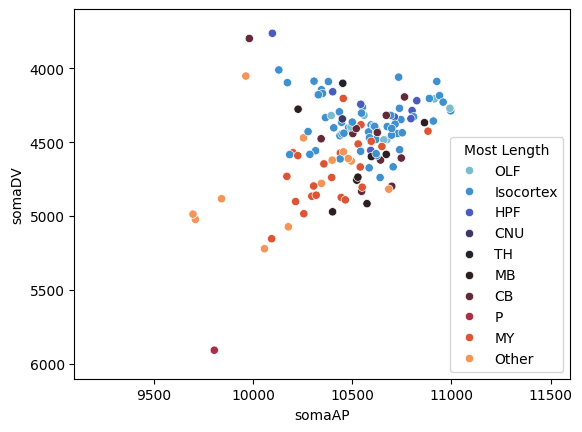

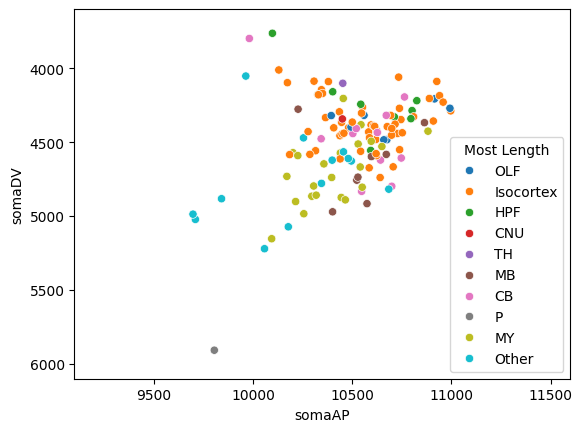

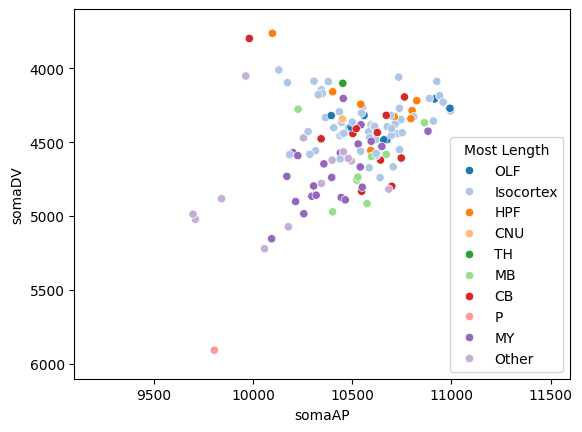

In [58]:
# Plot top projection target

# Only create colors for rois that are a top projection target
used_rois = sorted_rois.copy()
for indx in set(sorted_rois) - set(fullDF["Most Length"]):
    used_rois.remove(indx)

# Plot for several color palettes
for palette in ["plasma","icefire","tab10","tab20"]:
    plt.figure()
    sns.scatterplot(fullDF,x = "somaAP", y = "somaDV", hue = "Most Length", palette = palette, hue_order= used_rois)
    plt.xlim([9100, 11600])
    plt.ylim([3600, 6100])
    plt.gca().invert_yaxis() # Invert the y-axis
    plt.savefig(f"../results/top projection target soma location {palette} palette.svg",dpi=300, bbox_inches='tight')

In [ ]:
sns.scatterplot(pd.merge(dataDF, df.divide(df.sum(axis = 1), axis = 0), left_on = "Graph", right_index =True, how = "left"),
                x = "somaAP", y = "somaDV", hue = "isSpinalProjecting", palette = {False:"k", True:"tab:green"})
plt.xlim([9100, 11600])
plt.ylim([3600, 6100])
plt.gca().invert_yaxis() # Invert the y-axis
plt.savefig("../results/spinal projecting soma location.png",dpi=300, bbox_inches='tight')

In [ ]:
# Now lets visualize our clustering results.
dfPlotClustered = plotDF.copy()
# sort by projections
sortProjDict = {}
for i, col in enumerate(sorted_columns):
    sortProjDict[col] = i
dfPlotClustered["top proj"] = dfPlotClustered["top proj"].map(sortProjDict)
dfPlotClustered = dfPlotClustered.sort_values("top proj")[sorted_columns + ["Norm Total", "Norm Branches", "top proj"]]
# dfPlotClustered = plotDF.sort_values("top proj")[sorted_columns + ["top proj"]] # sort by cluster label to organize plot

# Plot the heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(dfPlotClustered.drop(columns=["top proj"]).T,  xticklabels=True, yticklabels=True)

# Outline clusters by drawing lines
# plt.yticks(rotation=0)
plt.gca().set_xticklabels([])
unique_clusters = dfPlotClustered["top proj"].unique()
plt.xlabel("Neuron")

plt.hlines([12], *plt.xlim(), colors = "white", linewidth = 2)
# plt.hlines([22], *plt.xlim(), colors = "white", linewidth = 2)

# for cluster in unique_clusters:
#     idx = np.where(dfPlotClustered["top proj"] == cluster)[0]
#     plt.vlines([min(idx), max(idx) + 1], *plt.ylim(), colors='white', linewidth=2)
plt.xticks(fontsize=7);
plt.savefig("../results/bilateral projection heatmap sorted by top projection target.svg",dpi=300,bbox_inches='tight', transparent = True)

## other

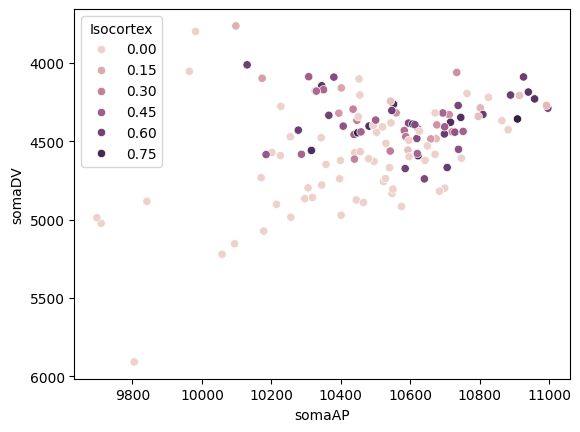

In [15]:
sns.scatterplot(pd.merge(dataDF, df.divide(df.sum(axis = 1), axis = 0), left_on = "Graph", right_index =True, how = "left"), x = "somaAP", y = "somaDV", hue = "Isocortex")
plt.gca().invert_yaxis() # Invert the y-axis

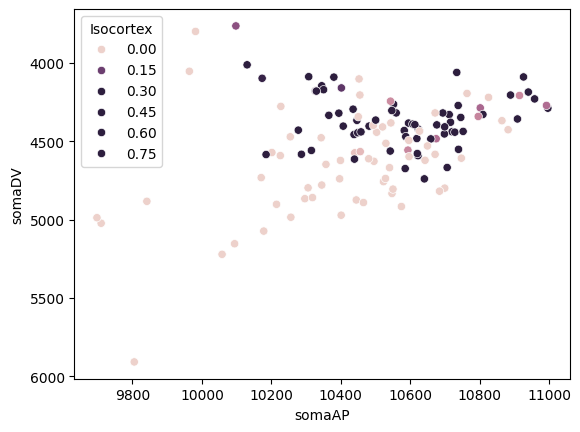

In [27]:
sns.scatterplot(pd.merge(dataDF, df.divide(df.sum(axis = 1), axis = 0), left_on = "Graph", right_index =True, how = "left"), x = "somaAP", y = "somaDV", hue = "Isocortex", hue_norm = (0, .2))
plt.gca().invert_yaxis() # Invert the y-axis

In [18]:
x = pd.merge(dataDF, df, left_on = "Graph", right_index =True, how = "left")
x[x['isSpinalProjecting']]

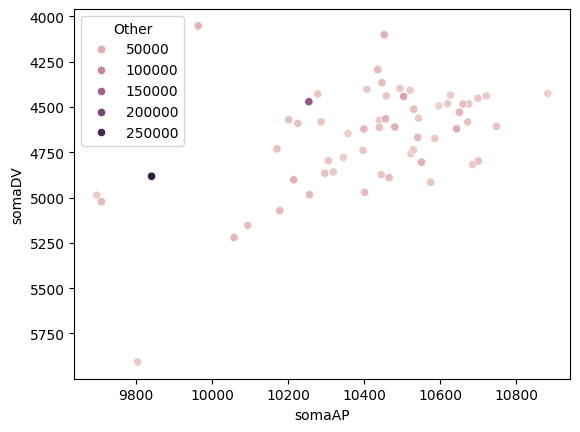

In [19]:
sns.scatterplot(x[x['isSpinalProjecting']], x = "somaAP", y = "somaDV", hue = "Other")
plt.gca().invert_yaxis() # Invert the y-axis

##### Volume comparisons

In [35]:
## Function to compute volume of CCF regions based upon mesh object volumes

def compute_mesh_volume(vertices, indices):
    volume = 0.0
    for tri in indices:  # Each `tri` is a list of 3 indices
        v1 = np.array(vertices[tri[0]])
        v2 = np.array(vertices[tri[1]])
        v3 = np.array(vertices[tri[2]])
        
        # Compute the signed volume of the tetrahedron
        tetra_volume = np.dot(v1, np.cross(v2, v3)) / 6.0
        volume += tetra_volume

    return abs(volume)  # Take absolute value to ensure positive volume

In [72]:
volDict = {}
rois = list(df.columns)
rois.remove("Other")
for name in rois:
    x = get_mesh_from_id(acronym_to_id[name])
    volDict[name] = compute_mesh_volume(x[0],x[2])

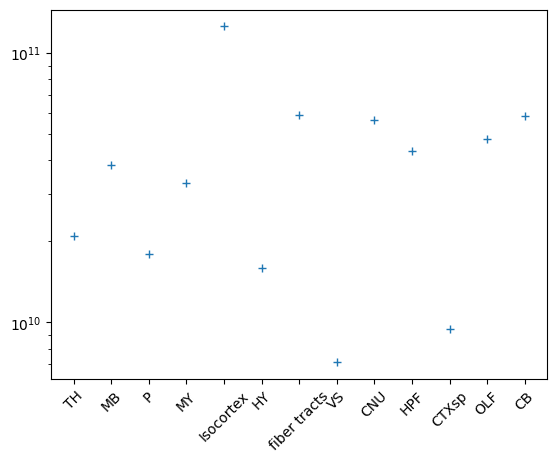

In [80]:
plt.plot(volDict.keys(),volDict.values(),'+')
plt.semilogy()
plt.xticks(rotation = 45);

### Plotting functions

In [32]:
# Establish camera views
topdownVertical = [12000, -10000, 5700, 9000, 0, 5700, -1, 0, 0]
topdownHorizontal = [9000, -9000, 5700, 9000, 0, 5700, 0, 0, 1]
topdownAngled = [7000, -12000, 0, 7000, 0, 5700, -.667, -.667, .167]
sideviewHorizontal = [7000, 5000, -8000, 7000, 4500, 5700, 0, -1, 0]

In [33]:
def load_obj(filename):
    """
    Load the vertices, vertex normals, and indices from a .obj file.

    Parameters:
    filename (str): Path to the .obj file

    Returns:
    tuple: A tuple containing three elements:
        - vertices (list of tuples): List of vertices, each vertex is a tuple (x, y, z)
        - normals (list of tuples): List of vertex normals, each normal is a tuple (nx, ny, nz)
        - indices (list of tuples): List of indices, each index is a tuple of vertex indices defining a face
    """
    vertices = []
    normals = []
    indices = []

    with open(filename, 'r') as file:
        for line in file:
            if line.startswith('v '):  # Vertex definition
                parts = line.split()
                vertices.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('vn '):  # Vertex normal definition
                parts = line.split()
                normals.append((float(parts[1]), float(parts[2]), float(parts[3])))
            elif line.startswith('f '):  # Face definition
                parts = line.split()
                # Extracting only the vertex indices (ignoring texture and normal indices)
                face_indices = [int(p.split('/')[0]) - 1 for p in parts[1:]]
                indices.append(tuple(face_indices))

    return vertices, normals, indices


def get_mesh_from_id(allen_id):
    obj_dir = "../data/ccf_2017_obj"
    obj_path = os.path.join(obj_dir, f"{allen_id}.obj")
    return load_obj(obj_path)

def rgb_to_hex(r,g,b):
    # Convert to a hexadecimal string
    hex_color = f'{r:02x}{g:02x}{b:02x}'
    # Convert the hexadecimal string to an integer in base-16
    color_int = int(hex_color, 16)
    return color_int

def plot_graphs(graphs, plot, color=0, opacity = 1, width = 1):
    for i, g in enumerate(graphs):
        g_lines = graph_to_lines(g, color, opacity, width)
        plot += g_lines

def graph_to_lines(g, color, opacity = 1, width = 1):
    # Extract vertex positions
    g_verts = np.array([g.nodes[n]['pos'] for n in sorted(g.nodes())], dtype=np.float32)
    # Pairs of indices into the vertex array are edges
    # Node keys start at 1, so offset by -1 to get indices
    g_inds = np.array([[u-1, v-1] for u, v in g.edges()], dtype=np.float32)
    g_lines = k3d.factory.lines(g_verts, g_inds, indices_type='segment', color=color, width=width, shader='simple', opacity = opacity)
    return g_lines

def plot_ccf_mesh(allen_id, plot, color=0x4d3d3d, opacity=0.1):
    vertices, normals, indices = get_mesh_from_id(allen_id)
    
    plt_tetra = k3d.mesh(
        vertices, 
        indices, 
        normals=normals,
        color=color,
        wireframe=False,
        opacity=opacity
    )

    plot += plt_tetra

In [34]:
# Get CCF lookups
from collections import defaultdict
ccf_structures = pd.read_csv('/data/allen_mouse_ccf/annotation/adult_mouse_ccf_structures.csv')
id_to_acronym = defaultdict(lambda: "NaN")
id_to_acronym = id_to_acronym | ccf_structures.set_index('id')['acronym'].to_dict()
acronym_to_id = {acronym: ccf_id for ccf_id, acronym in id_to_acronym.items()}
id_to_parent = ccf_structures.set_index('id')['parent_structure_id'].to_dict()
id_to_parent[None] = None # to account for out of bands points

### Plotting

In [12]:
# Plot single neuron, coloring out of bounds nodes
plotGraph = sc_dataDF["Graph"].iloc[12]#["N001-721332-HP"]

plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(sc_dataDF["Graph"]):
    if name in plotGraph:
        plot_graphs([graphs[name]],plot, opacity = .8)

# Set camera
plot.display()
plot.camera = topdownHorizontal

### Plot graphs outside of CCF bounds

In [15]:
# Plot single neuron, coloring out of bounds nodes
plotGraph = sc_dataDF["Graph"].iloc[13]
print(f"Plotting {plotGraph}")
plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(sc_dataDF["Graph"]):
    if name == plotGraph:
        plot_graphs_outside([graphs[name]],plot, acronym_to_color, opacity = .8)

# Set camera
plot.display()
plot.camera = sideviewHorizontal

In [16]:
colorList = [int("62728",16), int("2ca02c",16), int("FFA500",16),int("1f77b4",16)]
colorList = [int("62728",16), int("62728",16), int("2ca02c",16),int("2ca02c",16)]
colorList = [int("62728",16), int("2ca02c",16)]

colorDict = {"N015-721332-JG": int("2ca02c",16), "N004-721332-VM": int("2ca02c",16), "N001-721332-HP":int("62728",16), "N006-721332-JG":int("62728",16)}

In [21]:
sc_dataDF[sc_dataDF["Graph"].isin(plotGraph)]

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,completeSC
131,N001-721332-HP,N001,721332,HP,Dbh-Cre-KI/wt,10254.754578,4470.771631,4613.168027,False,True
127,N004-721332-VM,N004,721332,VM,Dbh-Cre-KI/wt,9841.552386,4882.454015,3951.691590,True,True
125,N006-721332-JG,N006,721332,JG,Dbh-Cre-KI/wt,10495.737911,4627.196463,4674.219950,False,True
126,N015-721332-JG,N015,721332,JG,Dbh-Cre-KI/wt,10452.779738,4101.540418,4831.008470,True,True


In [22]:
# Plot single neuron, coloring out of bounds nodes
colorDict = {"N015-721332-JG": int("2ca02c",16), "N004-721332-VM": int("2ca02c",16), "N001-721332-HP":int("62728",16), "N006-721332-JG":int("62728",16)}
plotGraph = ["N006-721332-JG", "N001-721332-HP", "N004-721332-VM", "N015-721332-JG"]


plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
for i, name in enumerate(sc_dataDF["Graph"]):
    if name in plotGraph:
        plot_graphs([graphs[name]],plot, color = colorDict[name], opacity = .8)

# Set camera
plot.display()
plot.camera = sideviewHorizontal

In [31]:
colorDict = {key: (int("2ca02c",16) if val > 5700 else int("62728",16)) for key, val in sc_dataDF[sc_dataDF["Graph"].isin(isSC)][["Graph","somaML"]].values}

In [34]:
# Plot single neuron, coloring out of bounds nodes
# plotGraph = ["N006-721332-JG", "N001-721332-HP", "N004-721332-VM", "N015-721332-JG"]
# plotGraph = ["N015-721332-JG","N006-721332-JG"]
# plotGraph = ["N015-721332-JG"]
# plotGraph = isSC
plotGraph = list(set(isSC) - set(["N006-721332-JG", "N001-721332-HP", "N004-721332-VM", "N015-721332-JG"]))

plot = k3d.plot()
plot_ccf_mesh(acronym_to_id['root'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
plot_ccf_mesh(acronym_to_id['TH'], plot, color=rgb_to_hex(128,128,128), opacity=0.05)
a = 0
for i, name in enumerate(sc_dataDF["Graph"]):
    if name in plotGraph:
        # plot_graphs([graphs[name]],plot, color = colorDict[name], opacity = .8)
        # plot_graphs([graphs[name]],plot, color = colorList[a], opacity = .8)
        plot_graphs([graphs[name]],plot, color = rgb_to_hex(int(255*np.random.rand()),int(255*np.random.rand()),int(255*np.random.rand())), opacity = .8)
        a = a + 1

# Set camera
plot.display()
plot.camera = sideviewHorizontal

## Look at axonal length

In [24]:
isSC = ["N002-721332-SA", "N021-721332-MB", "N017-721332-PP", "N014-721332-MB", "N007-721332-FB", 
        "N016-721332-PP", # maybe?
        "N006-721332-JG", "N015-721332-JG", "N004-721332-VM", "N001-721332-HP"]

In [27]:
# Get axonal lengths
df = clustering.build_length_df(sc_dataDF, graphs, DATA_DIR, normalize_df=False)
df = df.drop(list(set(df.index) - set(sc_dataDF["Graph"]))) # Drop graphs not included in dataDF

# Get axon branching
axon_branch_dict = {}
for name in sc_dataDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

# Combine length and branching into one dataframe
metricsDF = pd.concat([df.sum(axis=1) / 10000, pd.Series(axon_branch_dict)], axis = 1)
metricsDF = metricsDF.rename(columns = {0 : "Total Length (cm)", 1 : "Axon Branches"})
metricsDF

,Total Length (cm),Axon Branches
N021-721332-MB,34.273148,562
N003-721332-MB,14.603834,175
N020-721332-FB,37.021529,485
N005-721332-SP,23.012199,316
N017-721332-PP,18.905772,163
N010-721332-SP,42.472385,517
N008-721332-SA,27.472563,367
N009-721332-VM,35.100038,318
N006-721332-JG,24.301460,286
N015-721332-JG,28.105654,350


In [28]:
metricsDF["isSC"] = False
metricsDF.loc[metricsDF.index.isin(isSC),"isSC"] = True

In [29]:
isPlotted = ["N006-721332-JG", "N001-721332-HP", "N004-721332-VM", "N015-721332-JG"]
metricsDF["isPlotted"] = False
metricsDF.loc[metricsDF.index.isin(isPlotted),"isPlotted"] = True

(0.0, 3400.0)

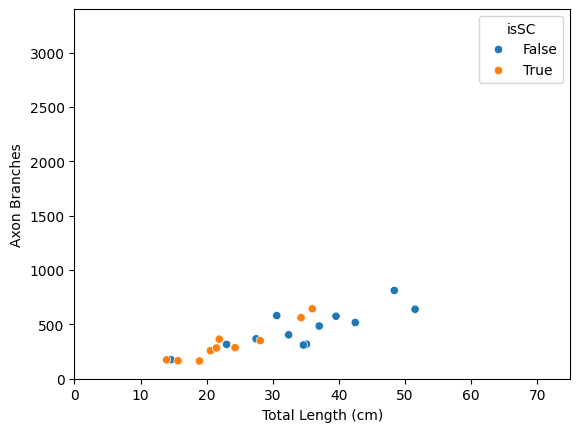

In [30]:
# sns.scatterplot(metricsDF,x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(metricsDF,x = "Total Length (cm)", y = "Axon Branches", hue = "isSC")
# sns.scatterplot(metricsDF,x = "Total Length (cm)", y = "Axon Branches", hue = "isPlotted")
plt.xlim([0, 75])
plt.ylim([0, 3400])

# sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
# sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
# plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
# plt.savefig("../results/LC total length vs branch count.svg",dpi=300,bbox_inches='tight')
# plt.savefig("../results/LC and Mouselight length vs branch count.svg",dpi=300,bbox_inches='tight')

## Integrate datasets

In [244]:
# Reflect graphs so all neuron somas are on the left hemisphere
mlMidline = 5700
mlReflection = mlMidline*2

# Add column for original soma side
sc_dataDF["somaOnRight"] = sc_dataDF["somaML"] > mlMidline

# Reflect rightside graphs across midline
for index, row in sc_dataDF.iterrows():
    # Grab neurons with somas on right
    if row["somaOnRight"]:
        sc_graph = sc_graphs[row["Graph"]]
        # Update soma position in dataframe
        sc_dataDF.loc[index,"somaML"] = mlReflection - sc_dataDF.loc[index,"somaML"]
        # Reflect every node's position along ML axis
        for node in sc_graph.nodes:
            sc_graph.nodes[node]["pos"] = (sc_graph.nodes[node]["pos"][0], sc_graph.nodes[node]["pos"][1], mlReflection - sc_graph.nodes[node]["pos"][2])

In [245]:
sc_dataDF

,Graph,ID,somaAP,somaDV,somaML,iSCL,somaOnRight
18,N001-721332-HP,N001-721332-HP,10254.754578,4470.771631,4613.168027,True,False
0,N002-721332-SA,N002-721332-SA,10642.887060,4620.827505,4609.366932,True,True
2,N003-721332-MB,N003-721332-MB,10763.834983,4194.155301,4620.913851,True,True
14,N004-721332-VM,N004-721332-VM,9841.552386,4882.454015,3951.691590,True,True
4,N005-721332-SP,N005-721332-SP,10455.186009,4204.146947,4695.605511,True,False
12,N006-721332-JG,N006-721332-JG,10495.737911,4627.196463,4674.219950,True,False
10,N007-721332-FB,N007-721332-FB,10530.133613,4512.370618,4593.485259,True,True
8,N008-721332-SA,N008-721332-SA,10227.469908,4276.754512,4825.895926,True,True
9,N009-721332-VM,N009-721332-VM,10552.281941,4263.100027,4745.043110,True,True
6,N010-721332-SP,N010-721332-SP,10547.222380,4303.248725,4692.614197,True,True


In [ ]:
# Add manual annotations of spinal projections
ctxAndSc = ['N030-685222-NM', 'N048-685221-VM', 'N044-685221-DS', 'N014-685221-YV', 'N022-685221-YP', 'N054-685221-HS', 'N052-685221-BP', 'N041-685221-JN', 'N038-685221-HS', 'N005-685222-YP',
 'N021-685222-NM', 'N016-685221-PG', 'N035-685221-DS', 'N016-685222-YP', 'N004-685222-BP', 'N010-685222-VM']

ibAndSc = ['N001-685221-PG', 'N043-685221-HD', 'N006-685222-DS', 'N007-685222-BP', 'N026-685222-SA', 'N051-685221-YP', 'N066-685221-JN', 'N039-685222-AK', 'N056-685221-AK', 'N042-685221-HD']

noCtxAndSc = ["N009-648434-KV", "N045-685221-VM","N034-685222-HD","N034-685221-VM","N057-685221-AP","N036-685221-YP", "N020-685221-BP", "N015-685222-VM", "N055-685221-JN", "N058-685221-JN", 
 "N046-685221-SA", "N060-685221-YV", "N025-648434-PG", "N013-685221-DS", "N012-685222-BP", "N013-685222-DS", "N050-685221-HD", "N024-685221-VM", "N008-685222-HD", "N009-685222-SP",
 "N024-685222-AP", "N059-685221-SA", "N012-648434-JN", "N006-648434-JN", "N025-685222-SA", "N061-685221-YP", "N030-685221-VM", "N026-648434-PG"]

dataDF["isSpinalProjecting"] = False
dataDF.loc[dataDF["Graph"].isin(ctxAndSc + ibAndSc + noCtxAndSc), "isSpinalProjecting"] = True

# Merge dataframes
dataDF["isML"] = False
sharedDF = pd.merge(dataDF,sc_dataDF, how = "outer")
# Join graph dictionaries
graphs.update(ml_graphs)


## Other

In [5]:
# Add manual annotations of spinal projections
ctxAndSc = ['N030-685222-NM', 'N048-685221-VM', 'N044-685221-DS', 'N014-685221-YV', 'N022-685221-YP', 'N054-685221-HS', 'N052-685221-BP', 'N041-685221-JN', 'N038-685221-HS', 'N005-685222-YP',
 'N021-685222-NM', 'N016-685221-PG', 'N035-685221-DS', 'N016-685222-YP', 'N004-685222-BP', 'N010-685222-VM']

ibAndSc = ['N001-685221-PG', 'N043-685221-HD', 'N006-685222-DS', 'N007-685222-BP', 'N026-685222-SA', 'N051-685221-YP', 'N066-685221-JN', 'N039-685222-AK', 'N056-685221-AK', 'N042-685221-HD']

noCtxAndSc = ["N009-648434-KV", "N045-685221-VM","N034-685222-HD","N034-685221-VM","N057-685221-AP","N036-685221-YP", "N020-685221-BP", "N015-685222-VM", "N055-685221-JN", "N058-685221-JN", 
 "N046-685221-SA", "N060-685221-YV", "N025-648434-PG", "N013-685221-DS", "N012-685222-BP", "N013-685222-DS", "N050-685221-HD", "N024-685221-VM", "N008-685222-HD", "N009-685222-SP",
 "N024-685222-AP", "N059-685221-SA", "N012-648434-JN", "N006-648434-JN", "N025-685222-SA", "N061-685221-YP", "N030-685221-VM", "N026-648434-PG"]

dataDF["isSpinalProjecting"] = False
dataDF.loc[dataDF["Graph"].isin(ctxAndSc + ibAndSc + noCtxAndSc), "isSpinalProjecting"] = True

# Merge dataframes
dataDF["isML"] = False
sharedDF = pd.merge(dataDF,ml_dataDF, how = "outer")
# Join graph dictionaries
graphs.update(ml_graphs)

In [6]:
# Get axonal lengths
df = clustering.build_length_df(sharedDF, graphs, DATA_DIR, normalize_df=False)
df = df.drop(list(set(df.index) - set(sharedDF["Graph"]))) # Drop graphs not included in dataDF

# Get axon branching
axon_branch_dict = {}
for name in sharedDF["Graph"]:
    graph = graphs[name]
    axon_branch_nodes = [node for node in graph.nodes() if graph.out_degree(node) > 1 and graph.nodes[node]["structure_id"] == 2]
    axon_branch_dict[name] = len(axon_branch_nodes)

# Combine length and branching into one dataframe
metricsDF = pd.concat([df.sum(axis=1) / 10000, pd.Series(axon_branch_dict)], axis = 1)
metricsDF = metricsDF.rename(columns = {0 : "Total Length (cm)", 1 : "Axon Branches"})
metricsDF

,Total Length (cm),Axon Branches
N003-685221-HS,39.771467,418
N001-685221-PG,14.318932,103
N004-685221-BP,40.529512,789
N011-685221-SP,54.236934,1045
N012-685221-SA,41.124639,846
...,...,...
AA1196,7.563850,630
AA0718,4.166692,278
AA0388,4.685182,345
AA1450,3.578115,359


In [7]:
# sharedDF= sharedDF.drop(columns = ["Total Length (cm)_x", "Total Length (cm)_y", "Axon Branches_x", "Axon Branches_y"])

In [8]:
# Merge onto sharedDF
sharedDF = pd.merge(sharedDF, metricsDF, left_on = "Graph", right_index =True, how = "left")
sharedDF

,Graph,ID,Sample,Annotator,Genotype,somaAP,somaDV,somaML,somaOnRight,isSpinalProjecting,isML,Total Length (cm),Axon Branches
0,N001-685221-PG,N001,685221,PG,Dbh-Cre-KI/wt,10201.676000,4571.162500,4612.849100,False,True,False,14.318932,103
1,N001-685222-SA,N001,685222,SA,Dbh-Cre-KI/wt,10345.217200,4145.213600,4709.684200,True,False,False,72.567420,982
2,N002-685222-HD,N002,685222,HD,Dbh-Cre-KI/wt,10559.816400,4318.414600,4715.990100,True,False,False,49.870732,809
3,N003-685221-HS,N003,685221,HS,Dbh-Cre-KI/wt,10481.613800,4402.569900,4750.009700,True,False,False,39.771467,418
4,N003-685222-JN,N003,685222,JN,Dbh-Cre-KI/wt,10544.454200,4382.014400,4718.210200,True,False,False,4.460401,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1330,AA1544,AA1544,NaN,NaN,NaN,4406.578656,1791.199431,4734.840768,NaN,NaN,True,6.958242,102
1331,AA1545,AA1545,NaN,NaN,NaN,7026.552532,4512.151424,4413.999972,NaN,NaN,True,6.196437,285
1332,AA1546,AA1546,NaN,NaN,NaN,6692.197461,4448.710096,4799.265709,NaN,NaN,True,6.148054,160
1333,AA1547,AA1547,NaN,NaN,NaN,6784.417886,3667.683656,3658.804733,NaN,NaN,True,3.703325,163


### Do plotting

In [11]:
sharedDF[~sharedDF["isML"]][["Graph","Total Length (cm)", "Axon Branches"]].to_csv("../results/LC length and branching.csv")

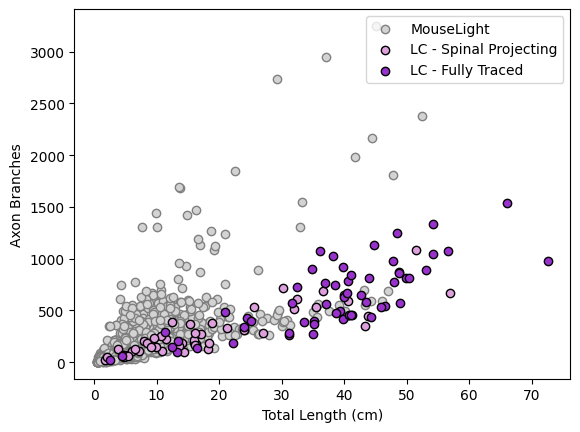

In [9]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
# plt.savefig("../results/LC total length vs branch count.svg",dpi=300,bbox_inches='tight')
plt.savefig("../results/LC and Mouselight length vs branch count.svg",dpi=300,bbox_inches='tight')

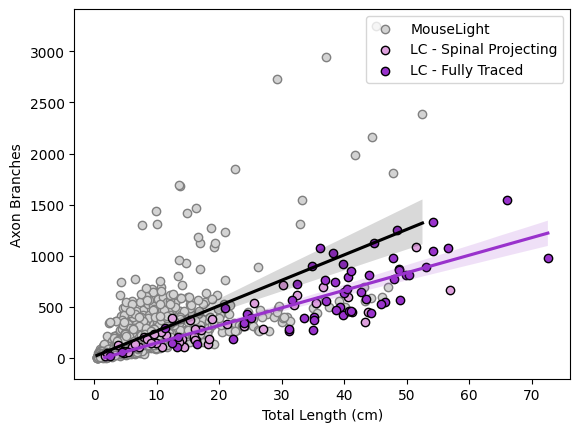

In [12]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
plt.savefig("../results/LC and Mouselight length vs branch count with regression and CI.svg",dpi=300,bbox_inches='tight')

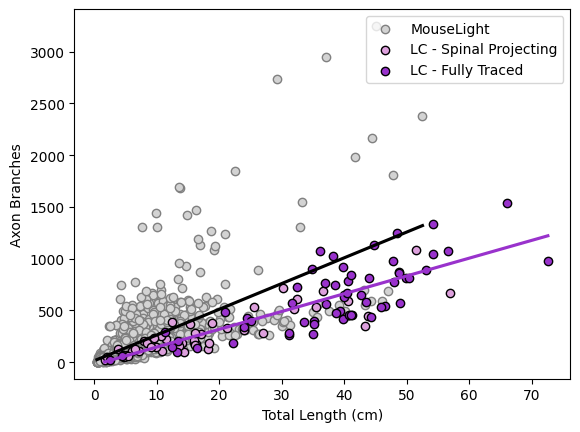

In [13]:
sns.scatterplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "gray", facecolor = "lightgray", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "Plum", linewidth = 1)
sns.scatterplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", edgecolor = "black", facecolor = "DarkOrchid", linewidth = 1)
plt.legend(["MouseLight","LC - Spinal Projecting","LC - Fully Traced"])
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False, ci = None)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False, ci = None)
plt.savefig("../results/LC and Mouselight length vs branch count with regression no CI.svg",dpi=300,bbox_inches='tight')

In [14]:
from scipy import stats

In [23]:
# Perform linear regression to get R-value
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[~sharedDF["isML"]]["Total Length (cm)"], 
                                                               sharedDF[~sharedDF["isML"]]["Axon Branches"])
# Calculate R-squared
r_squared = r_value**2
print(f"slope : {slope}")
print(f"intercept : {intercept}")
print(f"R^2 : {r_squared}")
print(f"pval : {p_value}")

slope : 17.18270815307419
intercept : -25.690499915328417
R^2 : 0.7410753595334758
pval : 7.081526440810124e-33


In [21]:
# Perform linear regression to get R-value
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[sharedDF["isML"]]["Total Length (cm)"], 
                                                               sharedDF[sharedDF["isML"]]["Axon Branches"])
# Calculate R-squared
r_squared = r_value**2
print(f"slope : {slope}")
print(f"intercept : {intercept}")
print(f"R^2 : {r_squared}")
print(f"pval : {p_value}")

slope : 24.870250026567188
intercept : 13.653056172509736
R^2 : 0.4172703801547808
pval : 7.864598272952046e-146


In [ ]:
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "black", scatter = False)
sns.regplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid", scatter = False)
# plt.savefig("../results/LC and Mouselight length vs branch count with regression and CI.svg",dpi=300,bbox_inches='tight')



<Axes: xlabel='Total Length (cm)', ylabel='Axon Branches'>

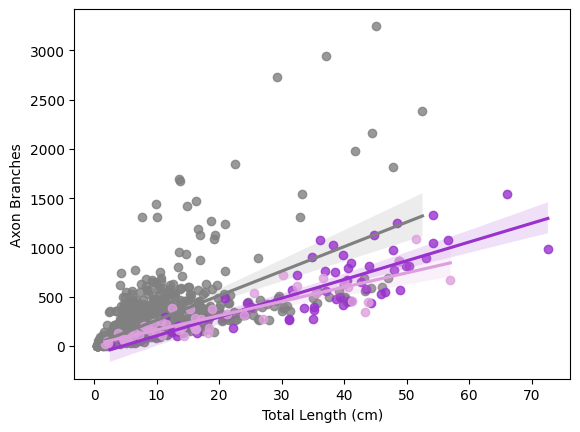

In [228]:
sns.regplot(sharedDF[sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches", color = "gray")
sns.regplot(sharedDF[sharedDF["isSpinalProjecting"] == False],x = "Total Length (cm)", y = "Axon Branches", color = "DarkOrchid")
sns.regplot(sharedDF[sharedDF["isSpinalProjecting"] == True],x = "Total Length (cm)", y = "Axon Branches", color = "Plum")

In [239]:
from scipy import stats

# Assuming 'df' from the regplot example
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[sharedDF["isML"]]["Total Length (cm)"], sharedDF[sharedDF["isML"]]["Axon Branches"])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

Slope: 24.870250026567188
Intercept: 13.653056172509736
R-squared: 0.4172703801547808


In [243]:
from scipy import stats

# Assuming 'df' from the regplot example
slope, intercept, r_value, p_value, std_err = stats.linregress(sharedDF[~sharedDF["isML"]]["Total Length (cm)"], sharedDF[~sharedDF["isML"]]["Axon Branches"])

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")

Slope: 17.18270815307419
Intercept: -25.690499915328417
R-squared: 0.7410753595334758


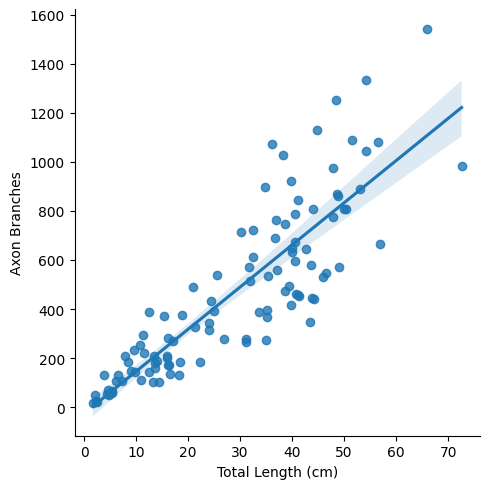

In [244]:
sns.lmplot(sharedDF[~sharedDF["isML"]],x = "Total Length (cm)", y = "Axon Branches")

### Perform axon length vs branching stats

In [247]:
pip install pandas statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 102.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 59.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [248]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [317]:
# Establish dataframe for fitting
fitDF = sharedDF[~sharedDF["isML"]][["isSpinalProjecting", "Total Length (cm)","Axon Branches"]].copy() # Subset to just LC neurons
fitDF.loc[fitDF["isSpinalProjecting"] == True,"Group"] = "A" # Spinal projecting is group A
fitDF.loc[fitDF["isSpinalProjecting"] == False,"Group"] = "B" # Non spinal projecting is group B
fitDF = fitDF.drop(columns = "isSpinalProjecting")
fitDF = fitDF.rename(columns = {"Total Length (cm)":"DependentVar","Axon Branches":"Covariate"})
fitDF

,DependentVar,Covariate,Group
0,14.318932,103,A
1,72.567420,982,B
2,49.870732,809,B
3,39.771467,418,B
4,4.460401,56,B
...,...,...,...
103,9.654440,232,A
104,25.510407,538,A
105,9.106368,148,A
106,54.180260,1332,B


In [321]:
# Establish dataframe for fitting
fitDF = sharedDF[["isML", "Total Length (cm)","Axon Branches"]].copy()
fitDF.loc[fitDF["isML"],"Group"] = "A" # Mouselight group is A
fitDF.loc[~fitDF["isML"],"Group"] = "B" # LC group is B
fitDF = fitDF.drop(columns = "isML")
fitDF = fitDF.rename(columns = {"Total Length (cm)":"DependentVar","Axon Branches":"Covariate"})
fitDF

,DependentVar,Covariate,Group
0,14.318932,103,B
1,72.567420,982,B
2,49.870732,809,B
3,39.771467,418,B
4,4.460401,56,B
...,...,...,...
1330,6.958242,102,A
1331,6.196437,285,A
1332,6.148054,160,A
1333,3.703325,163,A


In [314]:
# ANCOVA model: DependentVar ~ Group + Covariate
model = smf.ols('DependentVar ~ Group + Covariate', data=fitDF).fit()

In [315]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           DependentVar   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     1072.
Date:                Mon, 22 Sep 2025   Prob (F-statistic):          3.95e-278
Time:                        23:56:54   Log-Likelihood:                -4322.6
No. Observations:                1335   AIC:                             8651.
Df Residuals:                    1332   BIC:                             8667.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.8927      0.221     17.612      0.0

In [325]:
model.pvalues

Intercept      1.401597e-62
Group[T.B]    1.038319e-107
Covariate     6.346891e-172
dtype: float64